<div align="center">
    <h1> Delhivery Network Intelligence & Operations Strategy</h1>
    <h3>End-to-End Delay Prediction, Structural Bottleneck Audit, and Route Optimization</h3>
</div>

<br>

---


---

##  Phase 1: Data Engineering & The "Cumulative Trap"

###  Objective
The raw Delhivery dataset contains roughly 144,000 "snapshot" rows representing individual scanning segments. To build a reliable network graph and ETA model, we must transform this granular log into **one clean row per trip-leg** (a single continuous journey between two specific hubs). 

###  The "Cumulative Trap" & Aggregation Strategy
Aggregating logistics snapshot data requires precision. For instance, if a truck drives 50km, then another 50km, a naive sum on a cumulative distance column results in 150km (50 + 100), artificially inflating our network map. To prevent this, we applied strict mathematical logic to our grouping key (`trip_uuid` + `source` + `destination`):

* **Trip-Level Constants** (e.g., *Route Type, Creation Time*): Retained the `first()` recorded value.
* **Cumulative Metrics** (e.g., *OSRM Time, Distance*): Extracted the `max()` value to securely capture the final state of the leg.
* **Segment-Level Metrics** (e.g., *Segment Actual Time*): Applied a `sum()` to correctly tally the individual driving chunks.

###  Re-evaluating Lateness: Driving vs. Dwell
Derived operational metrics cannot simply be averaged across segments. They must be explicitly recomputed from the ground up after the roll-up to prevent mathematical distortion:
1. **True Delay Metrics:** We recalculated both the **Delay Factor** (Ratio: *How many times slower?*) and **Delay Minutes** (Absolute: *Total minutes lost*).
2. **Isolating Dwell Time:** A critical operational fix. By subtracting the truck's *actual movement time* from the *total wall-clock time* (start scan to end scan), we isolated the pure **Hub Processing (Dwell) Time**. This ensures our models can distinguish physical road traffic from facility-induced backlogs.



In [5]:
import pandas as pd

df = pd.read_csv("delivery_data.csv")
for c in ["trip_creation_time", "od_start_time", "od_end_time", "cutoff_timestamp"]:
    df[c] = pd.to_datetime(df[c], errors="coerce")

key = ["trip_uuid", "source_center", "destination_center", "od_start_time"]

legs = df.groupby(key, as_index=False).agg(
    data               = ("data", "first"),
    route_type         = ("route_type", "first"),
    trip_creation_time = ("trip_creation_time", "first"),
    source_name        = ("source_name", "first"),
    destination_name   = ("destination_name", "first"),
    od_end_time        = ("od_end_time", "first"),
    start_scan_to_end  = ("start_scan_to_end_scan", "first"),
    actual_time        = ("actual_time", "max"),
    osrm_time          = ("osrm_time", "max"),
    osrm_distance      = ("osrm_distance", "max"),
    actual_distance    = ("actual_distance_to_destination", "max"),
    seg_actual_sum     = ("segment_actual_time", "sum"),
    n_segments         = ("segment_actual_time", "size"),
)

# the two complementary measures
legs["delay_factor"]  = legs["actual_time"]/legs["osrm_time"]   
legs["delay_minutes"] = legs["actual_time"] - legs["osrm_time"]  

# dwell time ( i.e hub processing time calcn)
legs["hub_processing_time"] = legs["start_scan_to_end"] - legs["actual_time"]
legs["hub_processing_time"] = legs["hub_processing_time"].clip(lower=0)  

# Time + geography features
legs["hour"]      = legs["od_start_time"].dt.hour
legs["dayofweek"] = legs["od_start_time"].dt.dayofweek
legs["state"]     = legs["source_name"].str.extract(r"\(([^)]+)\)$")

legs = legs[(legs["osrm_time"] > 0) & (legs["actual_time"] > 0)].copy()
legs.to_csv("legs_clean_final.csv", index=False)

In [6]:
legs.head()

,trip_uuid,source_center,destination_center,od_start_time,data,route_type,trip_creation_time,source_name,destination_name,od_end_time,...,osrm_distance,actual_distance,seg_actual_sum,n_segments,delay_factor,delay_minutes,hub_processing_time,hour,dayofweek,state
0,trip-153671041653548748,IND209304AAA,IND000000ACB,2018-09-12 16:39:46.858469,training,FTL,2018-09-12 00:00:16.535741,Kanpur_Central_H_6 (Uttar Pradesh),Gurgaon_Bilaspur_HB (Haryana),2018-09-13 13:40:23.123744,...,446.5496,383.759164,728.0,18,2.097421,383.0,528.0,16,2,Uttar Pradesh
1,trip-153671041653548748,IND462022AAA,IND209304AAA,2018-09-12 00:00:16.535741,training,FTL,2018-09-12 00:00:16.535741,Bhopal_Trnsport_H (Madhya Pradesh),Kanpur_Central_H_6 (Uttar Pradesh),2018-09-12 16:39:46.858469,...,544.8027,440.973689,820.0,21,2.106599,436.0,169.0,0,2,Madhya Pradesh
2,trip-153671042288605164,IND561203AAB,IND562101AAA,2018-09-12 02:03:09.655591,training,Carting,2018-09-12 00:00:22.886430,Doddablpur_ChikaDPP_D (Karnataka),Chikblapur_ShntiSgr_D (Karnataka),2018-09-12 03:01:59.598855,...,28.1994,24.644021,46.0,3,1.807692,21.0,11.0,2,2,Karnataka
3,trip-153671042288605164,IND572101AAA,IND561203AAB,2018-09-12 00:00:22.886430,training,Carting,2018-09-12 00:00:22.886430,Tumkur_Veersagr_I (Karnataka),Doddablpur_ChikaDPP_D (Karnataka),2018-09-12 02:03:09.655591,...,56.9116,48.542890,95.0,6,2.285714,54.0,26.0,0,2,Karnataka
4,trip-153671043369099517,IND000000ACB,IND160002AAC,2018-09-14 03:40:17.106733,training,FTL,2018-09-12 00:00:33.691250,Gurgaon_Bilaspur_HB (Haryana),Chandigarh_Mehmdpur_H (Punjab),2018-09-14 17:34:55.442454,...,281.2109,242.309306,608.0,12,2.882075,399.0,223.0,3,4,Haryana


## Phase 2: Exploratory Data Analysis (EDA) 

###  Objective
The goal of this phase is to move beyond simple data profiling and quantify the core business problem. We must rigorously test the hypothesis that standard ETA predictions (OSRM) systematically fail in the real world, and understand exactly *where* and *why* those failures occur across the network.

###  Analysis
Instead of looking at raw aggregated time, we isolated specific delay metrics and stratified them across operational realities to find patterns. The analysis in the following code block executes the following:

* **The OSRM Reality Check:** We calculated the exact percentage of trips where OSRM underestimates actual time, and specifically mapped chronic delays (routes taking $>20\%$ longer than predicted).
* **Distribution Mapping:** Plotted the shape of the delay (both as a ratio and in absolute minutes) to prove whether lateness is caused by rare outliers or if it is a systemic network condition.
* **Operational Stratification:** * **Route Type:** Compared the delay profiles of FTL (Full Truck Load) vs. Carting (consolidated vans).
    * **Time of Day:** Mapped the median delay factor against the dispatch hour to identify peak congestion windows.
    * **Distance Bands:** Segmented trips (e.g., 0-50km vs. 600km+) to see if short-haul or long-haul routes suffer more relative delay.
* **Geographical Bottleneck Preview:** Aggregated delay and dwell times at the State, Facility, and specific Corridor levels to identify the absolute worst-performing geographic nodes before applying complex graph theory.





actual > OSRM            : 98.2% of legs
actual > OSRM by >20%    : 94.7% of legs
median delay factor      : 2.00x
median minutes lost      : 42 min
median dwell at hub      : 49 min


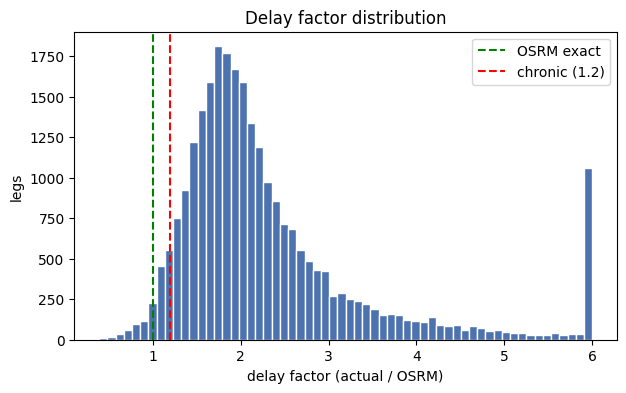

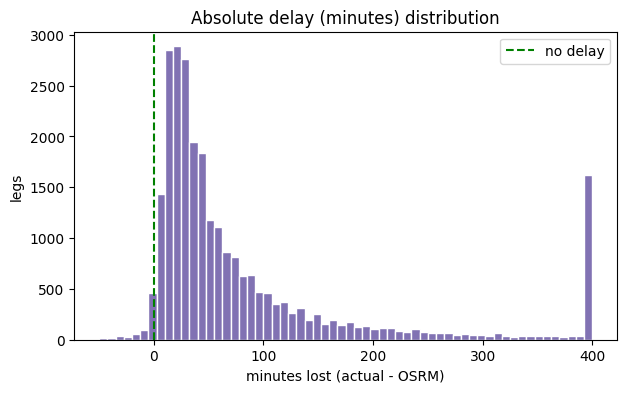


By route type (median):
            delay_factor  delay_minutes  hub_processing_time
route_type                                                  
Carting         2.153846           33.0                 50.0
FTL             1.925000           58.0                 47.0


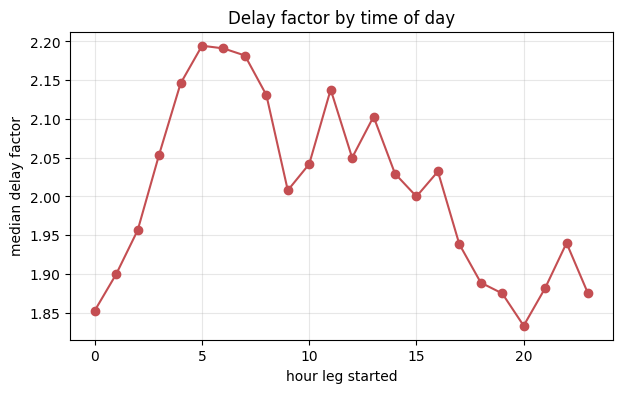


Median delay factor by distance band (km):
dist_bin
0-50       2.071429
50-150     1.950617
150-300    1.961777
300-600    1.975904
600+       1.937105
Name: delay_factor, dtype: float64

Worst hubs by median dwell time (>=50 legs):
                                      median_dwell  legs
source_name                                             
Hubli_Adargchi_IP (Karnataka)                393.0    78
Aluva_Peedika_H (Kerala)                     352.0    86
Aurangabad_Central_H_1 (Maharashtra)         257.5    58
Rampur_RoshnBgh_I (Uttar Pradesh)            218.0    67
Surat_HUB (Gujarat)                          179.0    93
Ranchi_Hub (Jharkhand)                       176.5    80
Coimbatore_Karayam_H (Tamil Nadu)            173.0    64
Jaipur_Hub (Rajasthan)                       173.0    96
Sonipat_Kundli_H (Haryana)                   169.0   245
Guwahati_Hub (Assam)                         168.0    90


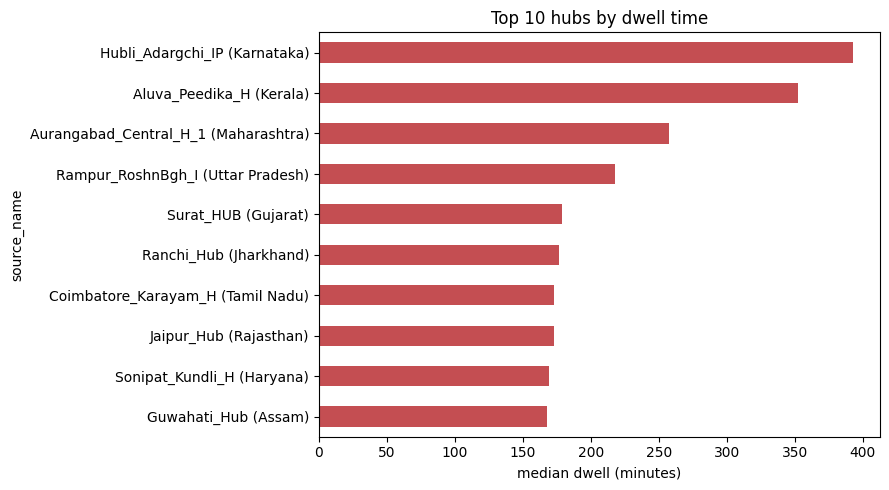


Worst states (>=100 legs):
                  median_factor  median_mins  legs
state                                             
West Bengal            2.577350         56.0  1368
Assam                  2.467376         62.5   484
Bihar                  2.384615         52.0  1060
Maharashtra            2.343653         44.0  3565
Jharkhand              2.310345        108.0   301
Himachal Pradesh       2.226766         62.0   223
Uttar Pradesh          2.098711         45.0  1832
Madhya Pradesh         2.079570         71.5   742
Orissa                 2.078820         83.5   248
Uttarakhand            2.000000         53.0   369

Worst busy corridors (>=30 legs):
                              median_factor  median_mins  legs
corridor                                                      
IND712310AAE -> IND712124AAA       3.730994         50.5    30
IND712311AAA -> IND700088AAA       3.586207         75.0    30
IND500010AAB -> IND501359AAE       3.378378         88.0    39
IND000000A

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

legs = pd.read_csv("legs_clean_final.csv")

# 1. baseline analysis
print(f"actual > OSRM            : {(legs.delay_factor > 1).mean()*100:.1f}% of legs")
print(f"actual > OSRM by >20%    : {(legs.delay_factor > 1.2).mean()*100:.1f}% of legs")
print(f"median delay factor      : {legs.delay_factor.median():.2f}x")
print(f"median minutes lost      : {legs.delay_minutes.median():.0f} min")
print(f"median dwell at hub      : {legs.hub_processing_time.median():.0f} min")

# 2. delay factor(ratio)
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(legs.delay_factor.clip(upper=6), bins=60, color="#4C72B0", edgecolor="white")
ax.axvline(1.0, color="green", ls="--", label="OSRM exact")
ax.axvline(1.2, color="red",   ls="--", label="chronic (1.2)")
ax.set(xlabel="delay factor (actual / OSRM)", ylabel="legs", title="Delay factor distribution")
ax.legend(); plt.show()

# 3. minutes lost
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(legs.delay_minutes.clip(lower=-50, upper=400), bins=60, color="#8172B3", edgecolor="white")
ax.axvline(0, color="green", ls="--", label="no delay")
ax.set(xlabel="minutes lost (actual - OSRM)", ylabel="legs", title="Absolute delay (minutes) distribution")
ax.legend(); plt.show()

# 4. route type
print("\nBy route type (median):")
print(legs.groupby("route_type")[["delay_factor", "delay_minutes", "hub_processing_time"]].median())

# 5. hour of day
by_hour = legs.groupby("hour")["delay_factor"].median()
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(by_hour.index, by_hour.values, marker="o", color="#C44E52")
ax.set(xlabel="hour leg started", ylabel="median delay factor", title="Delay factor by time of day")
ax.grid(alpha=0.3); plt.show()

# 6. distance
legs["dist_bin"] = pd.cut(legs.osrm_distance, [0,50,150,300,600,1e5],
                          labels=["0-50","50-150","150-300","300-600","600+"])
print("\nMedian delay factor by distance band (km):")
print(legs.groupby("dist_bin", observed=True)["delay_factor"].median())

# 7. dwell time
hub_dwell = (legs.groupby("source_name")
                 .agg(median_dwell=("hub_processing_time", "median"), legs=("hub_processing_time", "size"))
                 .query("legs >= 50")
                 .sort_values("median_dwell", ascending=False)
                 .head(10))
print("\nWorst hubs by median dwell time (>=50 legs):")
print(hub_dwell)
fig, ax = plt.subplots(figsize=(9, 5))
hub_dwell["median_dwell"].iloc[::-1].plot(kind="barh", color="#C44E52", ax=ax)
ax.set(xlabel="median dwell (minutes)", title="Top 10 hubs by dwell time"); plt.tight_layout(); plt.show()

# 8. worst states and corridors
print("\nWorst states (>=100 legs):")
print(legs.groupby("state")
          .agg(median_factor=("delay_factor","median"), median_mins=("delay_minutes","median"), legs=("delay_factor","size"))
          .query("legs >= 100").sort_values("median_factor", ascending=False).head(10))

legs["corridor"] = legs.source_center + " -> " + legs.destination_center
print("\nWorst busy corridors (>=30 legs):")
print(legs.groupby("corridor")
          .agg(median_factor=("delay_factor","median"), median_mins=("delay_minutes","median"), legs=("delay_factor","size"))
          .query("legs >= 30").sort_values("median_factor", ascending=False).head(10))

## Phase 3: Network Graph Construction

###  Objective
we translate our cleaned tabular data into a **Directed Weighted Graph**—a map of the Delhivery logistics network.

###  Graph
We utilized graph theory to map and structure the data as follows:
* **Nodes (Facilities/ Hubs):** Every unique source and destination center serves as a distinct node.
* **Edges (Corridors):** The physical lanes connecting two facilities. We specifically built a *Directed* Graph (`DiGraph`) because traffic patterns and delays are fundamentally asymmetric (e.g., Gurgaon $\rightarrow$ Bangalore operates under different conditions than Bangalore $\rightarrow$ Gurgaon).
* **Edge Weights :** The weight of traveling each edge is defined as the **Median Delay Factor**. 

###  Stratification 
1. **By Route Type:** We isolated the exact median delay factor for FTL (Full Truck Load) versus Carting (consolidated vans) on the exact same physical road.
2. **By Time of Day:** We bucketed dispatch hours into four distinct operational windows (Night, Morning, Afternoon, Evening), capturing how network chokepoints shift throughout a 24-hour cycle.

In [8]:
import pandas as pd
import networkx as nx

legs = pd.read_csv("legs_clean_final.csv")

# time-of-day(tod) stratification
def bucket(h):
    return "night" if h < 6 else "morning" if h < 12 else "afternoon" if h < 18 else "evening"
legs["tod"] = legs["hour"].apply(bucket)

# aggregating legs into corridors
corr = legs.groupby(["source_center", "destination_center"]).agg(
    median_delay_factor   = ("delay_factor",        "median"),   # edge weight
    median_delay_minutes  = ("delay_minutes",       "median"),
    median_hub_processing = ("hub_processing_time", "median"),
    median_osrm_distance  = ("osrm_distance",       "median"),
    n_legs                = ("trip_uuid",           "size"),
).reset_index()

# stratifying the delay factor by route type and by time of day 
for strat in ["route_type", "tod"]:
    s = (legs.groupby(["source_center", "destination_center", strat])["delay_factor"]
             .median().unstack())
    s.columns = [f"median_delay_factor_{c}" for c in s.columns]
    corr = corr.merge(s, on=["source_center", "destination_center"], how="left")

# building the directed weighted graph
G = nx.DiGraph()
for _, r in corr.iterrows():
    G.add_edge(r.source_center, r.destination_center,
               weight   = r.median_delay_factor,      
               n_legs   = r.n_legs,
               dwell    = r.median_hub_processing,
               minutes  = r.median_delay_minutes)

# node names
names = (pd.concat([legs[["source_center","source_name"]].rename(columns={"source_center":"c","source_name":"n"}),
                    legs[["destination_center","destination_name"]].rename(columns={"destination_center":"c","destination_name":"n"})])
           .dropna().drop_duplicates("c").set_index("c")["n"].to_dict())
nx.set_node_attributes(G, names, "name")

corr.to_csv("corridors_named.csv", index=False)
print("nodes:", G.number_of_nodes(), "edges:", G.number_of_edges())

nodes: 1657 edges: 2783


### Network Visualization ( using PyVis)
In this visualization :
* **Edge Thickness (Volume):** Represents the absolute traffic load (`n_legs`). Thicker lines highlight the heaviest-trafficked corridors.
* **Hover:** Hovering over any lane reveals its weight (`median_delay_factor`)

In [10]:
from pyvis.network import Network
import pandas as pd, networkx as nx

corr = pd.read_csv("corridors_named.csv")
G = nx.DiGraph()
for _, r in corr.iterrows():
    G.add_edge(r.source_center, r.destination_center,
               value=float(r.n_legs),                       # edge thickness is traffic
               title=f"delay {r.median_delay_factor:.2f}")  # hovering shows delay
net = Network(height="800px", width="100%", directed=True, notebook=False)
net.from_nx(G)
net.write_html("network.html")     

## Phase 4: Structural Bottleneck & Corridor Audit

###  Objective
Having established that delays are systemic, we must now locate the exact physical nodes (hubs) causing the delay.

###  Metrics
For every facility in the network, we calculated four metrics:

1. **Betweenness Centrality:** Measures how often a hub sits on the shortest path between two other nodes. A high betweenness score indicates a hub with massive network power; if it fails, the entire network fails because there are no workarounds.
2. **In/Out-Degree:** The count of corridors leading into and out of a facility. High degree implies high consolidation complexity.
3. **Clustering Coefficient:** Measures how well a hub's neighbors are connected to *each other*. A low clustering score indicates a fragile "hub-and-spoke" dependency, where the central hub is an un-bypassable single point of failure.
4. **SLA-Breach Contribution:** We calculated the exact percentage of the *total network delayed minutes* that originated from each specific facility, multiplying severity by volume to find the actual pain points.

###  Chronic Corridors
Beyond the hubs, we audited the edges. We flagged "Chronic Corridors"—physical lanes where the median transit time is consistently >20% worse than OSRM estimates. By sorting these by absolute minutes lost, we instantly prioritized the lanes requiring immediate operational intervention (like shifting from Carting to FTL).

In [11]:
import pandas as pd
import networkx as nx

corr = pd.read_csv("corridors_named.csv")
legs = pd.read_csv("legs_clean_final.csv")

# building graph
G = nx.DiGraph()
for _, r in corr.iterrows():
    G.add_edge(r.source_center, r.destination_center,
               weight=r.median_delay_factor, n_legs=r.n_legs)
Gc = G.subgraph(max(nx.weakly_connected_components(G), key=len)).copy()
print(f"full: {G.number_of_nodes()} nodes / {G.number_of_edges()} edges | "
      f"core (largest CC): {Gc.number_of_nodes()} nodes")

# metrics
indeg  = pd.Series(dict(G.in_degree()))                             # Metric 1: degree 
outdeg = pd.Series(dict(G.out_degree()))
btw    = pd.Series(nx.betweenness_centrality(Gc, normalized=True))  # Metric 2: betweenness 
clust  = pd.Series(nx.clustering(Gc))                               # Metric 3: clustering 

# metric 4 : sla breach contribution
net_total = legs["delay_minutes"].sum()                            
breach = (legs.groupby("source_center")
              .agg(total_excess_min  = ("delay_minutes",       "sum"),
                   n_legs_dispatched = ("delay_minutes",       "size"),
                   median_dwell      = ("hub_processing_time", "median")))
breach["pct_network_delay"] = breach.total_excess_min / net_total * 100

# new csv formation with new columns as bottleneck factors
names = (pd.concat([
            legs[["source_center","source_name"]].rename(columns={"source_center":"c","source_name":"n"}),
            legs[["destination_center","destination_name"]].rename(columns={"destination_center":"c","destination_name":"n"})])
         .dropna().drop_duplicates("c").set_index("c")["n"])
nodes = pd.DataFrame({"in_deg":indeg, "out_deg":outdeg,
                      "betweenness":btw, "clustering":clust}).join(breach)
nodes["name"] = nodes.index.map(names)
nodes[["betweenness","clustering"]] = nodes[["betweenness","clustering"]].fillna(0)  
nodes = nodes.fillna(0)
nodes.to_csv("hub_metrics.csv")

# chronic corridors
corr["chronic"] = corr.median_delay_factor > 1.2                   # >20% over OSRM
corr_excess = (legs.groupby(["source_center","destination_center"])["delay_minutes"]
                   .sum().rename("total_excess_min").reset_index())
corr = corr.merge(corr_excess, on=["source_center","destination_center"])
corr.to_csv("corridors_bottleneck.csv", index=False)

# printing the results
print("\nTOP 8 BOTTLENECK HUBS (by % network delay)")
print(nodes.sort_values("pct_network_delay", ascending=False).head(8)
      [["name","pct_network_delay","betweenness","in_deg","out_deg","clustering","median_dwell"]].round(3).to_string())

print(f"\nchronic corridors: {corr.chronic.sum()} of {len(corr)} ({corr.chronic.mean()*100:.0f}%)")
print("\nTOP 8 CHRONIC CORRIDORS (by total late-minutes)")
print(corr[corr.chronic].sort_values("total_excess_min", ascending=False).head(8)
      [["source_center","destination_center","median_delay_factor","n_legs","total_excess_min"]].round(1).to_string(index=False))

full: 1657 nodes / 2783 edges | core (largest CC): 1353 nodes

TOP 8 BOTTLENECK HUBS (by % network delay)
                                           name  pct_network_delay  betweenness  in_deg  out_deg  clustering  median_dwell
IND000000ACB      Gurgaon_Bilaspur_HB (Haryana)             14.685        0.330      45       49       0.027         155.0
IND421302AAG  Bhiwandi_Mankoli_HB (Maharashtra)              6.345        0.104      29       29       0.059         142.0
IND562132AAA   Bangalore_Nelmngla_H (Karnataka)              5.461        0.187      36       35       0.055         140.0
IND411033AAA      Pune_Tathawde_H (Maharashtra)              2.584        0.065      23       20       0.053         112.0
IND712311AAA   Kolkata_Dankuni_HB (West Bengal)              2.431        0.136      24       22       0.032         116.5
IND501359AAE   Hyderabad_Shamshbd_H (Telangana)              2.078        0.139      30       27       0.037         160.0
IND781018AAB               Guwaha

### Bottleneck Visualization (PyVis)
we generated a interactive map isolating the top 45 most critical structural chokepoints.

In this visualization:
* **Node Size (Chokepoint Risk):** Driven by Betweenness Centrality. Larger hubs represent structural single points of failure.
* **Node Color (SLA Impact):** Driven by the percentage of total network delay. Dark red nodes represent the primary locations where time is bleeding.
* **Edge Mapping:** Thickness represents traffic volume, while the color gradient (yellow to dark red) maps the severity of the delay factor.

In [12]:
import pandas as pd, networkx as nx
from pyvis.network import Network
import matplotlib.cm as cm, matplotlib.colors as mcolors

corr = pd.read_csv("corridors_named.csv")
m    = pd.read_csv("hub_metrics.csv", index_col=0)

TOPN = 45
top = m.sort_values("betweenness", ascending=False).head(TOPN).index.tolist()
sub = corr[(corr.source_center.isin(top)) & (corr.destination_center.isin(top))]

def red(x, lo, hi):                                   # value in red/orange hex
    return mcolors.to_hex(cm.YlOrRd(min(max((x-lo)/(hi-lo), 0), 1)))

net = Network(height="800px", width="100%", directed=True,
              bgcolor="#0e1117", font_color="#e6e6e6", notebook=False)
net.barnes_hut(gravity=-9000, central_gravity=0.25, spring_length=130, spring_strength=0.02)

# for nodes: size = betweenness, colour = share in delay
for n in top:
    row   = m.loc[n]
    city  = row["name"].split("_")[0]
    state = row["name"].split("(")[-1].rstrip(")") if "(" in row["name"] else ""
    net.add_node(
        n, label=city,
        size=14 + row.betweenness*160,
        color={"background": red(row.pct_network_delay, 0, 16),
               "border": "#222", "highlight": {"background": "#ffd24d", "border": "#000"}},
        borderWidth=1.5, font={"size": 16, "color": "#ffffff", "strokeWidth": 3, "strokeColor": "#000"},
        title=(f"<b>{row['name']}</b><br>State: {state}<br>━━━━━━━━━━<br>"
               f"Delay share: <b>{row.pct_network_delay:.1f}%</b> of network<br>"
               f"Betweenness: <b>{row.betweenness:.3f}</b><br>"
               f"In / Out corridors: {int(row.in_deg)} / {int(row.out_deg)}<br>"
               f"Clustering: {row.clustering:.3f}<br>"
               f"Median dwell: {row.median_dwell:.0f} min<br>"
               f"Legs dispatched: {int(row.n_legs_dispatched)}"))

# for edges: width = traffic, colour = delay factor
for _, r in sub.iterrows():
    net.add_edge(r.source_center, r.destination_center,
                 width=1 + r.n_legs/12,
                 color=red(r.median_delay_factor, 1, 3),
                 title=(f"{r.median_delay_factor:.2f}x slower than OSRM<br>"
                        f"{int(r.n_legs)} legs &middot; {r.median_delay_minutes:.0f} min median delay"))

net.write_html("bottlenecks_pro.html")

# injecting legend and title overlay
legend = """
<div style="position:fixed;top:14px;left:14px;background:rgba(20,24,31,.94);color:#e6e6e6;
border:1px solid #333;border-radius:10px;padding:14px 16px;font-family:system-ui,sans-serif;
font-size:13px;z-index:999;box-shadow:0 4px 14px rgba(0,0,0,.5);max-width:270px;">
<div style="font-size:15px;font-weight:700;margin-bottom:2px;">Delhivery Bottleneck Network</div>
<div style="color:#9aa;font-size:11px;margin-bottom:8px;">Top 45 hubs by chokepoint score</div>
<div style="margin:6px 0;"><b>Node size</b> &rarr; betweenness (chokepoint risk)</div>
<div><b>Node colour</b> &rarr; % of total network delay</div>
<div style="height:11px;width:200px;border-radius:3px;margin:5px 0;
background:linear-gradient(to right,#ffffcc,#feb24c,#f03b20,#bd0026);"></div>
<div style="display:flex;justify-content:space-between;font-size:11px;color:#9aa;width:200px;">
<span>0%</span><span>8%</span><span>16%+</span></div>
<div style="margin:8px 0 2px;"><b>Edge width</b> &rarr; traffic (number of legs)</div>
<div><b>Edge colour</b> &rarr; corridor delay factor (red = worse)</div>
<hr style="border-color:#333;margin:9px 0;">
<div style="font-size:11px;color:#9aa;">Hover a hub for full metrics &middot; drag &middot; scroll to zoom</div>
</div>
"""
html = open("bottlenecks_pro.html").read().replace("<body>", "<body>" + legend)
open("bottlenecks_pro.html", "w").write(html)
print("wrote bottlenecks_pro.html")

wrote bottlenecks_pro.html


###  Executive Charting: Bottleneck Profiles
While the interactive map provides full network context, we also generated static charts to clearly rank and isolate the worst offenders for reporting and presentation purposes. 

* **Chart A (SLA Impact):** Ranks the top 10 hubs by their total percentage contribution to network delay.
* **Chart B (Structural Risk):** Ranks the top 10 hubs by Betweenness Centrality, highlighting the most fragile routing chokepoints.
* **Chart C (Lane-Level Failures):** Identifies the top 10 chronic corridors, sorted by total accumulated late minutes.
* **Chart D (Risk vs. Impact Scatter):** Plots structural chokepoint risk against actual SLA impact. This proves that structural routing power directly correlates with delays, visually isolating massive outliers like Gurgaon.

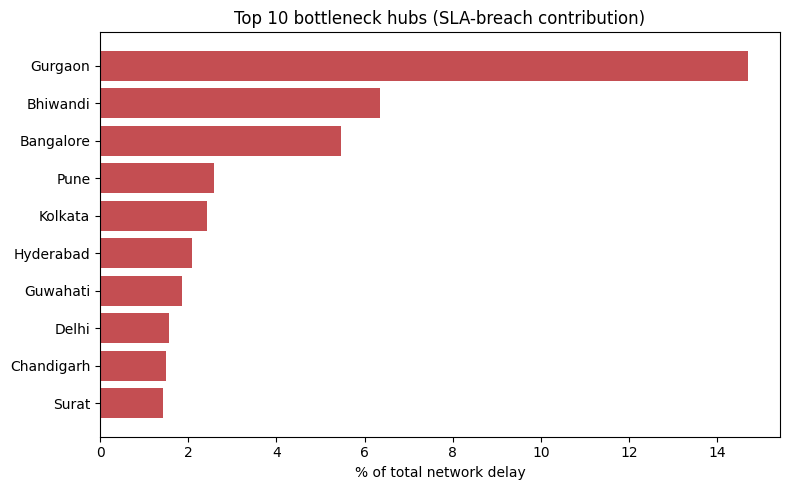

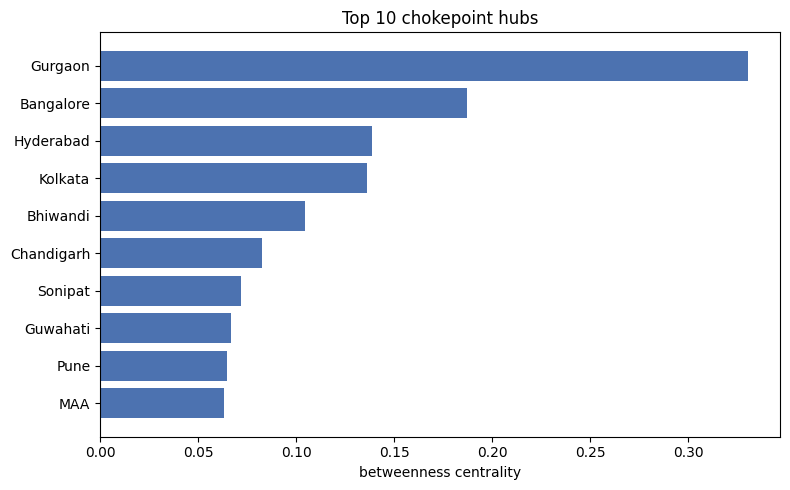

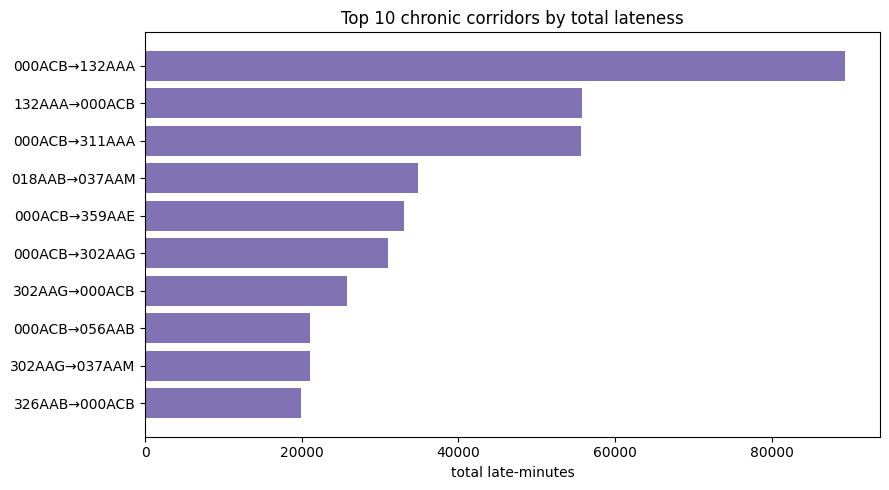

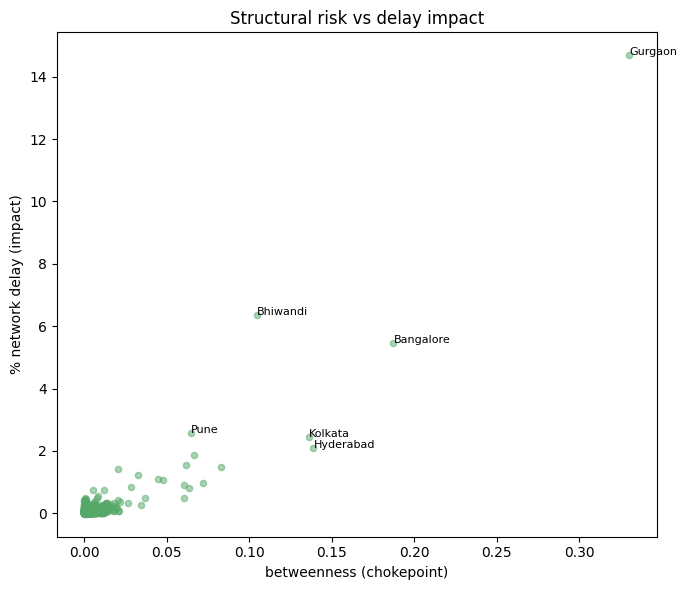

In [13]:
import pandas as pd, matplotlib.pyplot as plt

m    = pd.read_csv("hub_metrics.csv", index_col=0)
corr = pd.read_csv("corridors_bottleneck.csv")

short = lambda s: s.str.split("_").str[0]  

# Chart A
top = m.sort_values("pct_network_delay", ascending=False).head(10)
fig, ax = plt.subplots(figsize=(8,5))
ax.barh(short(top["name"])[::-1], top["pct_network_delay"][::-1], color="#C44E52")
ax.set(xlabel="% of total network delay", title="Top 10 bottleneck hubs (SLA-breach contribution)")
plt.tight_layout(); plt.show()

# Chart B
topb = m.sort_values("betweenness", ascending=False).head(10)
fig, ax = plt.subplots(figsize=(8,5))
ax.barh(short(topb["name"])[::-1], topb["betweenness"][::-1], color="#4C72B0")
ax.set(xlabel="betweenness centrality", title="Top 10 chokepoint hubs")
plt.tight_layout(); plt.show()

# Chart C
tc = corr[corr.chronic].sort_values("total_excess_min", ascending=False).head(10)
labels = (tc.source_center.str[-6:] + "→" + tc.destination_center.str[-6:])
fig, ax = plt.subplots(figsize=(9,5))
ax.barh(labels[::-1], tc["total_excess_min"][::-1], color="#8172B3")
ax.set(xlabel="total late-minutes", title="Top 10 chronic corridors by total lateness")
plt.tight_layout(); plt.show()

# Chart D
fig, ax = plt.subplots(figsize=(7,6))
ax.scatter(m["betweenness"], m["pct_network_delay"], s=20, alpha=.5, color="#55A868")
for n in m.sort_values("pct_network_delay", ascending=False).head(6).index:
    ax.annotate(short(pd.Series([m.loc[n,"name"]])).iloc[0],
                (m.loc[n,"betweenness"], m.loc[n,"pct_network_delay"]), fontsize=8)
ax.set(xlabel="betweenness (chokepoint)", ylabel="% network delay (impact)",
       title="Structural risk vs delay impact")
plt.tight_layout(); plt.show()

## Phase 5: Graph-Enhanced ETA Model 

###  Objective
Traditional ETA models fail because they treat every shipment in isolation. Our goal in this phase is to predict the actual delivery time and rigorously prove that granting an ML model "spatial awareness" of the network topology significantly reduces prediction errors.

###  Model Architectures
We deployed a high-performance Gradient Boosting algorithm (`HistGradientBoostingRegressor`) to benchmark three distinct levels of intelligence:

1. **Baseline:** Relies purely on standard features (OSRM estimated time, physical distance, route type, and time of day). This model is completely blind to network cascading effects.
2. **Node2Vec:** We mapped the physical network and deployed a Node2Vec algorithm ("Word2Vec for graphs"). By simulating random walks across the corridors, we generated 16-dimensional spatial coordinates for every hub, teaching the model *where* a route sits within the broader network.
3. **GraphSAGE:** We built a customized Deep Learning Graph Neural Network using PyTorch. GraphSAGE goes beyond simple map structure; it mathematically aggregates the actual congestion features (Betweenness Centrality, In/Out-Degree) of downstream hubs, allowing the model to "see" traffic jams forming ahead of the truck.

###  Evaluation Metrics
* **Mean Absolute Error (MAE):** The average deviation from reality, measured in absolute minutes.
* **15% SLA Compliance:** The percentage of total trips that arrived within a strict 15% margin of the model's quoted ETA. 

In [17]:
import pandas as pd, numpy as np, networkx as nx
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error
from node2vec import Node2Vec

legs = pd.read_csv("legs_clean_final.csv")
corr = pd.read_csv("corridors_bottleneck.csv")
legs["is_ftl"] = (legs.route_type == "FTL").astype(int)
base = ["osrm_time", "osrm_distance", "is_ftl", "hour", "dayofweek"]
w15  = lambda yt, yp: (np.abs(yp - yt) / yt <= 0.15).mean() * 100

def evaluate(df, cols, tag):                       # trained on provided split, scored on test
    tr, te = df[df.data == "training"], df[df.data == "test"]
    m = HistGradientBoostingRegressor(random_state=42).fit(tr[cols], tr.actual_time)
    p = m.predict(te[cols])
    print(f"{tag:24}: MAE {mean_absolute_error(te.actual_time, p):6.1f} | within15 {w15(te.actual_time, p):5.1f}%")

# Baseline
evaluate(legs, base, "1. BASELINE")

# node2vec embeddings as features
G = nx.from_pandas_edgelist(corr, "source_center", "destination_center", create_using=nx.DiGraph())
DIM = 16
n2v = Node2Vec(G, dimensions=DIM, walk_length=15, num_walks=10, workers=2, quiet=True).fit(window=5, min_count=1)
emb = {n: n2v.wv[n] for n in G.nodes()}; zero = np.zeros(DIM)
src = np.vstack(legs.source_center.map(lambda s: emb.get(s, zero)).to_numpy())
dst = np.vstack(legs.destination_center.map(lambda s: emb.get(s, zero)).to_numpy())
cols2 = [f"src{i}" for i in range(DIM)] + [f"dst{i}" for i in range(DIM)]
legs[cols2] = np.hstack([src, dst])
evaluate(legs, base + cols2, "2. BASELINE + node2vec")

# GraphSAGE embeddings as features
import torch, torch.nn.functional as F
from torch_geometric.nn import SAGEConv
from torch_geometric.utils import negative_sampling

hub = pd.read_csv("hub_metrics.csv", index_col=0)
nodes_list = list(G.nodes()); idx = {n: i for i, n in enumerate(nodes_list)}
edge_index = torch.tensor([[idx[u] for u, v in G.edges()],
                           [idx[v] for u, v in G.edges()]], dtype=torch.long)
fcols = ["in_deg", "out_deg", "betweenness", "clustering"]                 # initial node features
X = torch.tensor(hub.reindex(nodes_list)[fcols].fillna(0).values, dtype=torch.float)

class SAGE(torch.nn.Module):
    def __init__(s, i, h, o): super().__init__(); s.c1 = SAGEConv(i, h); s.c2 = SAGEConv(h, o)
    def forward(s, x, ei):    return s.c2(F.relu(s.c1(x, ei)), ei)

model = SAGE(len(fcols), 32, DIM); opt = torch.optim.Adam(model.parameters(), lr=0.01)
for _ in range(60):                                                       # unsupervised training
    model.train(); opt.zero_grad()
    z = model(X, edge_index)
    pos = (z[edge_index[0]] * z[edge_index[1]]).sum(-1)
    neg = negative_sampling(edge_index, num_nodes=len(nodes_list))
    negs = (z[neg[0]] * z[neg[1]]).sum(-1)
    loss = -F.logsigmoid(pos).mean() - F.logsigmoid(-negs).mean()          # neighbors close, others far
    loss.backward(); opt.step()
z = z.detach().numpy(); sage = {n: z[idx[n]] for n in nodes_list}
s2 = np.vstack(legs.source_center.map(lambda s: sage.get(s, np.zeros(DIM))).to_numpy())
d2 = np.vstack(legs.destination_center.map(lambda s: sage.get(s, np.zeros(DIM))).to_numpy())
cols3 = [f"sg_s{i}" for i in range(DIM)] + [f"sg_d{i}" for i in range(DIM)]
legs[cols3] = np.hstack([s2, d2])
evaluate(legs, base + cols3, "3. BASELINE + GraphSAGE")

1. BASELINE             : MAE   50.5 | within15  27.9%
2. BASELINE + node2vec  : MAE   37.1 | within15  36.8%
3. BASELINE + GraphSAGE : MAE   37.9 | within15  36.9%


## Phase 6: FTL vs. Carting Strategy

###  Objective
In this phase, we built a decision framework to determine when operations should pay the premium for FTL/carting.

###  Counterfactual Simulation
We cannot simply compare historical FTL trips to historical Carting trips, because FTLs are historically biased toward specific, high-volume routes, which skews the raw averages. Instead, we used a machine learning technique called **Counterfactual Inference**. 

For every single trip in the database, we cloned the data and simulated two alternate realities using our trained model:
1. **Reality A (Forced FTL):** Predicted transit time if the route was driven by a dedicated truck.
2. **Reality B (Forced Carting):** Predicted transit time if the route was forced through consolidation.

By subtracting the two predictions, we isolated the pure time advantage (minutes saved) of an FTL on any given physical lane, entirely taking away the noise of distance or time of day.

###  Cost-Benefit
We mapped an illustrative financial cost per kilometer to both vehicle types (e.g., INR 30 vs. INR 12) to calculate the exact price premium of an FTL upgrade. Finally, we aggregated these thousands of simulations to the **Corridor Level** and applied a hard business rule: an FTL is only recommended if it reliably saves $>30$ minutes of transit time, justifying its premium. Otherwise, the algorithm defaults the lane to Carting to protect profit margins.

In [20]:
import pandas as pd, numpy as np
from sklearn.ensemble import HistGradientBoostingRegressor

legs = pd.read_csv("legs_clean_final.csv")
legs["is_ftl"] = (legs.route_type == "FTL").astype(int)
base = ["osrm_time", "osrm_distance", "is_ftl", "hour", "dayofweek"]

m = HistGradientBoostingRegressor(random_state=42).fit(
        legs[legs.data=="training"][base], legs[legs.data=="training"].actual_time)

# counterfactual
Xf = legs[base].copy(); Xf["is_ftl"] = 1
Xc = legs[base].copy(); Xc["is_ftl"] = 0
legs["t_ftl"]            = m.predict(Xf)
legs["t_carting"]        = m.predict(Xc)
legs["mins_saved_by_ftl"] = legs.t_carting - legs.t_ftl     # FTL's time advantage

# illustrative cost premium (can be replaced with real Rs/km rate)
C_FTL, C_CART = 30, 12
legs["extra_cost_ftl"] = legs.osrm_distance * (C_FTL - C_CART)

# corridor-level recommendation
corr = legs.groupby(["source_center","destination_center"]).agg(
    dist_km        = ("osrm_distance",     "median"),
    mins_saved_ftl = ("mins_saved_by_ftl", "median"),
    extra_cost_ftl = ("extra_cost_ftl",    "median"),
    n_legs         = ("is_ftl",            "size")).reset_index()
corr["recommend"] = np.where(corr.mins_saved_ftl > 30, "FTL", "Carting")   # FTL if it saves >30 min
print(corr.recommend.value_counts())

recommend
Carting    2563
FTL         220
Name: count, dtype: int64


###  Model Execution

* **Prediction Pipelines :**
    * **Baseline Model:** Trains on standard trip features (distance, OSRM time, route type, hour) to establish a point-to-point benchmark without network awareness.
    * **Node2Vec Enhancements:** Maps the network graph, generates structural spatial coordinates for each hub, and feeds them into the regressor to capture topological positioning.
    * **GraphSAGE Deep Learning:** Deploys a Graph Neural Network in PyTorch to aggregate downstream congestion features, allowing the model to look ahead for bottlenecks.
* **Evaluation:** * Restricts predictions strictly to the out-of-sample test set to prevent data leakage.
    * Calculates a strict **10% SLA Accuracy Metric**, measuring exactly what percentage of our predictions landed within a 10% margin of error of the true driving time. 
    * Finally, it gives the `legs_with_predictions.csv`.

In [29]:
import pandas as pd
import numpy as np
import networkx as nx
from sklearn.ensemble import HistGradientBoostingRegressor
from node2vec import Node2Vec
import torch
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv
from torch_geometric.utils import negative_sampling

legs = pd.read_csv("legs_clean_final.csv")
corr = pd.read_csv("corridors_bottleneck.csv")
hub = pd.read_csv("hub_metrics.csv", index_col=0)

legs["is_ftl"] = (legs.route_type == "FTL").astype(int)
base = ["osrm_time", "osrm_distance", "is_ftl", "hour", "dayofweek"]
train_mask = legs.data == "training"
test_mask = legs.data == "test"

legs["pred_baseline"] = np.nan
legs["pred_node2vec"] = np.nan
legs["pred_graphsage"] = np.nan

# baseline model
print("Generating Baseline predictions...")
m_base = HistGradientBoostingRegressor(random_state=42)
m_base.fit(legs[train_mask][base], legs[train_mask].actual_time)
legs.loc[test_mask, "pred_baseline"] = m_base.predict(legs[test_mask][base])

# node2vec
print("Generating Node2Vec predictions...")
G = nx.from_pandas_edgelist(corr, "source_center", "destination_center", create_using=nx.DiGraph())
DIM = 16

n2v = Node2Vec(G, dimensions=DIM, walk_length=15, num_walks=10, workers=2, quiet=True).fit(window=5, min_count=1)
emb = {n: n2v.wv[n] for n in G.nodes()}
zero = np.zeros(DIM)

src_n2v = np.vstack(legs.source_center.map(lambda s: emb.get(s, zero)).to_numpy())
dst_n2v = np.vstack(legs.destination_center.map(lambda s: emb.get(s, zero)).to_numpy())
cols_n2v = [f"src{i}" for i in range(DIM)] + [f"dst{i}" for i in range(DIM)]
legs[cols_n2v] = np.hstack([src_n2v, dst_n2v])

m_n2v = HistGradientBoostingRegressor(random_state=42)
m_n2v.fit(legs[train_mask][base + cols_n2v], legs[train_mask].actual_time)

legs.loc[test_mask, "pred_node2vec"] = m_n2v.predict(legs[test_mask][base + cols_n2v])

# GraphSAGE
print("Generating GraphSAGE predictions...")
nodes_list = list(G.nodes())
idx = {n: i for i, n in enumerate(nodes_list)}
edge_index = torch.tensor([[idx[u] for u, v in G.edges()],
                           [idx[v] for u, v in G.edges()]], dtype=torch.long)

fcols = ["in_deg", "out_deg", "betweenness", "clustering"]
X = torch.tensor(hub.reindex(nodes_list)[fcols].fillna(0).values, dtype=torch.float)

class SAGE(torch.nn.Module):
    def __init__(s, i, h, o): 
        super().__init__()
        s.c1 = SAGEConv(i, h)
        s.c2 = SAGEConv(h, o)
    def forward(s, x, ei):    
        return s.c2(F.relu(s.c1(x, ei)), ei)

model = SAGE(len(fcols), 32, DIM)
opt = torch.optim.Adam(model.parameters(), lr=0.01)

for _ in range(60):
    model.train()
    opt.zero_grad()
    z = model(X, edge_index)
    pos = (z[edge_index[0]] * z[edge_index[1]]).sum(-1)
    neg = negative_sampling(edge_index, num_nodes=len(nodes_list))
    negs = (z[neg[0]] * z[neg[1]]).sum(-1)
    loss = -F.logsigmoid(pos).mean() - F.logsigmoid(-negs).mean()
    loss.backward()
    opt.step()

z = z.detach().numpy()
sage_emb = {n: z[idx[n]] for n in nodes_list}

src_sage = np.vstack(legs.source_center.map(lambda s: sage_emb.get(s, np.zeros(DIM))).to_numpy())
dst_sage = np.vstack(legs.destination_center.map(lambda s: sage_emb.get(s, np.zeros(DIM))).to_numpy())
cols_sage = [f"sg_s{i}" for i in range(DIM)] + [f"sg_d{i}" for i in range(DIM)]
legs[cols_sage] = np.hstack([src_sage, dst_sage])

m_sage = HistGradientBoostingRegressor(random_state=42)
m_sage.fit(legs[train_mask][base + cols_sage], legs[train_mask].actual_time)

legs.loc[test_mask, "pred_graphsage"] = m_sage.predict(legs[test_mask][base + cols_sage])


print("\n--- Model Performance (Test Set: within 10% of Actual Time) ---")
def within_10_percent(y_true, y_pred):
    return (np.abs(y_pred - y_true) / y_true <= 0.10).mean() * 100

y_test = legs[test_mask]["actual_time"]

base_10 = within_10_percent(y_test, legs.loc[test_mask, "pred_baseline"])
n2v_10  = within_10_percent(y_test, legs.loc[test_mask, "pred_node2vec"])
sage_10 = within_10_percent(y_test, legs.loc[test_mask, "pred_graphsage"])

print(f"Baseline (Tabular) : {base_10:.1f}%")
print(f"Node2Vec Enhanced  : {n2v_10:.1f}%")
print(f"GraphSAGE Enhanced : {sage_10:.1f}%")

legs_final = legs.drop(columns=cols_n2v + cols_sage)
output_file = "legs_with_predictions.csv"
legs_final.to_csv(output_file, index=False)

Generating Baseline predictions...
Generating Node2Vec predictions...
Generating GraphSAGE predictions...

--- Model Performance (Test Set: within 10% of Actual Time) ---
Baseline (Tabular) : 19.4%
Node2Vec Enhanced  : 25.7%
GraphSAGE Enhanced : 25.3%
